# Single-Cell Isoform Analysis with Allos

This tutorial walks through a complete single-cell isoform analysis workflow using the **allos** library.  
We use a mouse E18 brain dataset (Sicelore, Oxford Nanopore) comprising ~1,100 cells across two technical replicates.

Standard droplet-based scRNA-seq (e.g. 10x Chromium) reads only ~100 bp at one end of each cDNA — enough for gene-level counts, but it discards information on **alternative splicing, RNA editing and allele-specific expression**. Long-read sequencing (Oxford Nanopore, PacBio) delivers reads that span entire transcripts, directly revealing exon structure and enabling isoform-resolved single-cell transcriptomics.

**What you'll learn:**
1. Loading and merging long-read scRNA-seq isoform matrices
2. Quality control and preprocessing
3. Cell-type validation with canonical marker genes
4. Differential isoform usage (DIU) with SwitchSearch
5. Publication-ready composed figures
6. Protein domain visualisation — linking splicing changes to functional protein regions

## 1. Setup

[**Allos**](https://github.com/cobioda/allos) is a Python toolkit for isoform-resolved single-cell and spatial transcriptomics, built on the scverse/AnnData ecosystem. It provides rapid differential isoform usage screening (`SwitchSearch`), publication-quality composed plots that align transcript structures with quantitative expression panels, read-level coverage visualisation, and protein domain overlay — bridging the gap between gene-level scRNA-seq workflows and the full transcript diversity captured by long-read sequencing (McAndrew *et al.*, 2026; [bioRxiv 10.64898/2026.03.24.713944](https://www.biorxiv.org/content/10.64898/2026.03.24.713944v1)).

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import scanpy as sc
import matplotlib.pyplot as plt

import allos.preprocessing as pp
from allos.transcript_data import TranscriptData
from allos.transcript_plots import TranscriptPlots
from allos.switch_search import SwitchSearch, get_top_n_isoforms
from allos.composed_plots import (
    plot_isoform_heatmap_composed,
    plot_isoform_dot_composed,
    plot_isoform_violin_composed,
    plot_isoform_stacked_bar_composed,
    plot_isoform_umap_composed,
    plot_isoform_density_composed,
)

sc.settings.verbosity = 1

# ── Consistent cell-type order and colours across all plots ──
CELL_TYPE_ORDER = [
    "radial glia",
    "cycling radial glia",
    "intermediate progenitor",
    "imature Glutamatergic",
    "mature Glutamatergic",
    "imature GABAergic",
    "mature GABAergic",
    "Cajal-Retzius",
]

CELL_TYPE_COLORS = {
    "radial glia":             "#4E79A7",
    "cycling radial glia":     "#59A14F",
    "intermediate progenitor": "#EDC948",
    "imature Glutamatergic":   "#F28E2B",
    "mature Glutamatergic":    "#E15759",
    "imature GABAergic":       "#76B7B2",
    "mature GABAergic":        "#B07AA1",
    "Cajal-Retzius":           "#9C755F",
}

CELL_TYPE_PALETTE = [CELL_TYPE_COLORS[ct] for ct in CELL_TYPE_ORDER]

print('allos loaded successfully')

allos loaded successfully


## 2. Load Data

The isoform count matrix is stored as an **AnnData** object — the standard data structure in the scverse ecosystem. It organises the expression matrix (`.X`) alongside cell-level metadata (`.obs`, e.g. cell type, batch) and feature-level metadata (`.var`, e.g. gene ID, transcript ID). This lets us carry isoform-resolution counts through the same scanpy workflows used for gene-level analysis.

In [ ]:
# Load isoform count data
adata = pp.process_mouse_data()
adata


🔎 Looking for file at: /data/analysis/data_mcandrew/00_allos_manuscript/allos_clean/allos/resources/e18.mouse.clusters.csv
✅ File found at: /data/analysis/data_mcandrew/00_allos_manuscript/allos_clean/allos/resources/e18.mouse.clusters.csv
✅ File already exists at: /data/analysis/data_mcandrew/00_allos_manuscript/allos_clean/allos/resources/data/mouse_1.txt.gz

🔄 Decompressing /data/analysis/data_mcandrew/00_allos_manuscript/allos_clean/allos/resources/data/mouse_1.txt.gz to /data/analysis/data_mcandrew/00_allos_manuscript/allos_clean/allos/resources/data/mouse_1.txt...
✅ Decompression complete.
Test data (mouse_1) downloaded successfully
✅ File already exists at: /data/analysis/data_mcandrew/00_allos_manuscript/allos_clean/allos/resources/data/mouse_2.txt.gz

🔄 Decompressing /data/analysis/data_mcandrew/00_allos_manuscript/allos_clean/allos/resources/data/mouse_2.txt.gz to /data/analysis/data_mcandrew/00_allos_manuscript/allos_clean/allos/resources/data/mouse_2.txt...
✅ Decompression

View of AnnData object with n_obs × n_vars = 1109 × 31986
    obs: 'batch', 'cell_type'
    var: 'geneId', 'transcriptId'

In [ ]:
# Load GTF annotation
GTF_PATH = '/data/analysis/data_mcandrew/00_allos_manuscript/allos/data/Mus_musculus.GRCm39.109.gtf.gz'
td = TranscriptData(GTF_PATH)
tp = TranscriptPlots(transcript_data=td)

In [ ]:
print(f'Cells: {adata.n_obs}')
print(f'Transcripts: {adata.n_vars}')
print(f'Cell types: {adata.obs.cell_type.nunique()}')
print()
adata.obs.cell_type.value_counts()

Cells: 1109
Transcripts: 31986
Cell types: 8



mature Glutamatergic       275
imature Glutamatergic      234
mature GABAergic           172
imature GABAergic          141
cycling radial glia        117
intermediate progenitor     86
radial glia                 68
Cajal-Retzius               16
Name: cell_type, dtype: int64

### Dataset overview

| Parameter | Value | Notes |
|-----------|-------|-------|
| Source tissue | E18 mouse cortex + hippocampus | Late-gestation brain, rich in neurogenesis |
| Cells profiled | 951 + 190 technical replicates | Split at emulsion step |
| Reads | 322M + 32M Nanopore; 70M + 43M Illumina | PromethION + NextSeq |
| Median genes / cell (Illumina) | 2,739 | Gene-level reference |
| Median isoform UMIs / cell (Nanopore) | 3,795 | After CB/UMI assignment |

The data was generated using the **ScNaUmi-seq** workflow, which combines 10x droplet barcoding with full-length Nanopore sequencing. Matched Illumina short-read data guides barcode/UMI recovery, achieving ~99.8% barcode and ~97% UMI accuracy. Reads sharing a UMI are collapsed into high-accuracy consensus sequences per molecule.

## 3. Preprocessing

Long-read isoform matrices are wide — many rare splice variants appear in only a handful of cells. We filter these out to reduce noise and speed up downstream analysis. We then inspect the dataset composition before moving to dimensionality reduction.

In [ ]:
adata = pp.filter_transcripts_by_abundance(adata, threshold_pct=2, verbose=True)
adata

Filtering transcripts: keeping 24917 out of 31986 transcripts (threshold = 2%).


AnnData object with n_obs × n_vars = 1109 × 24917
    obs: 'batch', 'cell_type'
    var: 'geneId', 'transcriptId'

### Quality control

These diagnostic plots summarise the isoform landscape after filtering:
- **Isoforms per gene:** Most genes have 1–3 detected isoforms; a long tail reflects genes with complex alternative splicing.
- **Transcript lengths:** Distribution of annotated transcript lengths for detected isoforms — long-read platforms recover full-length molecules, so this should span a wide range.
- **Biotype breakdown:** Fraction of detected transcripts by Ensembl biotype (protein-coding, lncRNA, etc.).

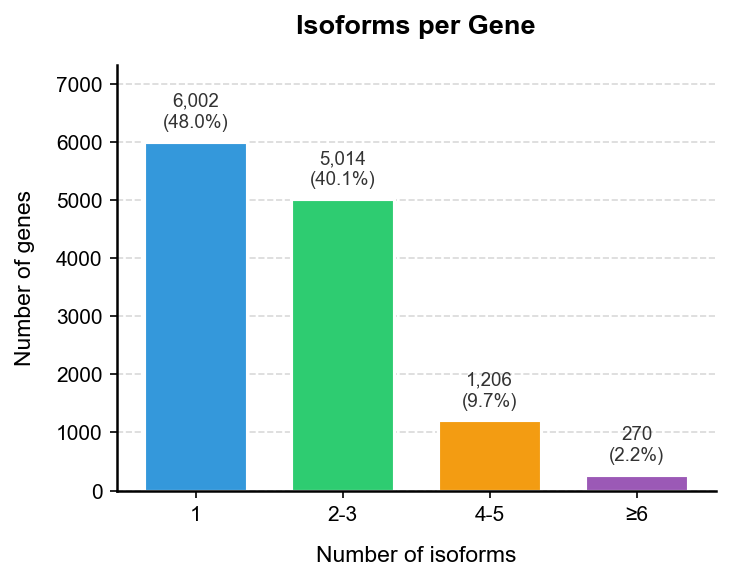

In [ ]:
pp.plot_isoforms_per_gene(td, adata=adata)
plt.show()

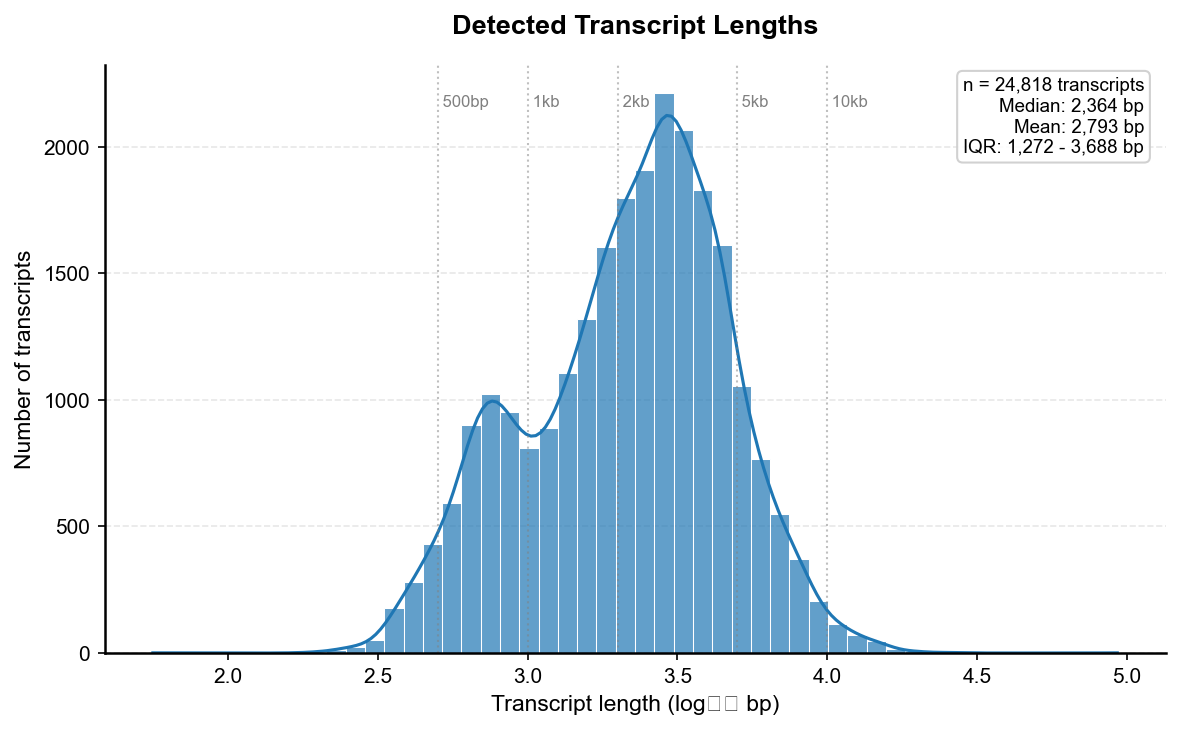

In [ ]:
pp.plot_detected_transcript_lengths(td, adata)
plt.show()

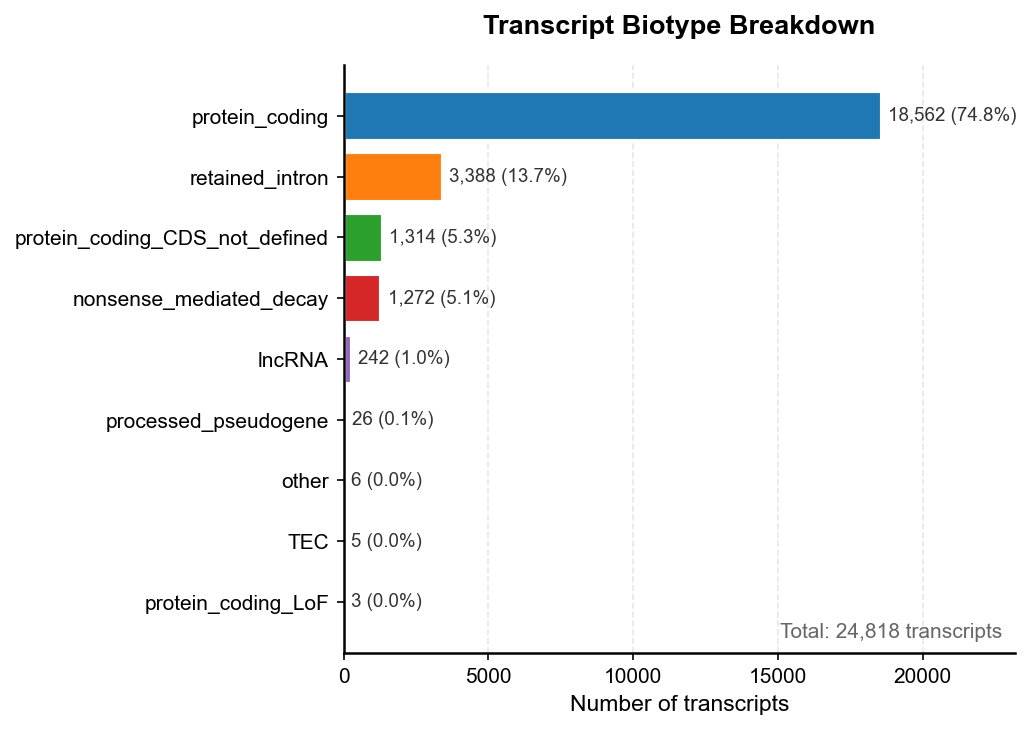

In [ ]:
pp.plot_biotype_breakdown(td, adata)
plt.show()

### Gene-level UMAP

To identify cell types we collapse the isoform matrix to gene level and run standard scanpy dimensionality reduction. Whether you feed PCA/UMAP the gene-level or isoform-level matrix, the clusters are typically near-identical — cell identity is driven by aggregate gene expression, not individual splice variants. We use the gene matrix here and transfer UMAP coordinates back to the isoform AnnData for downstream visualisation.

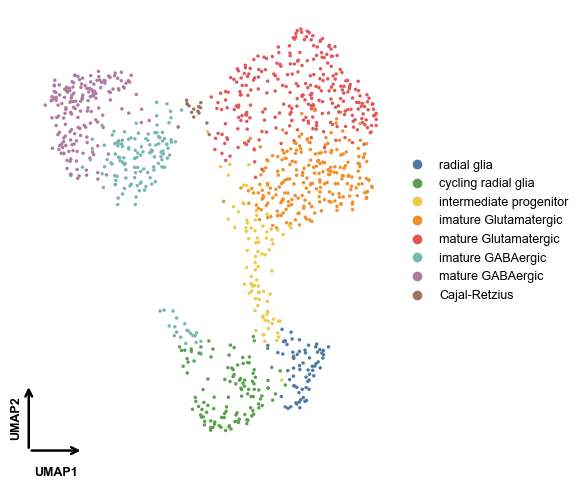

In [ ]:
gene_adata = pp.get_sot_gene_matrix(adata)

sc.pp.normalize_total(gene_adata, target_sum=1e4)
sc.pp.log1p(gene_adata)
sc.pp.highly_variable_genes(gene_adata)
sc.pp.pca(gene_adata)
sc.pp.neighbors(gene_adata)
sc.tl.umap(gene_adata)

# Register palette with scanpy so all sc.pl calls use it
gene_adata.obs["cell_type"] = gene_adata.obs["cell_type"].astype("category")
gene_adata.obs["cell_type"] = gene_adata.obs["cell_type"].cat.reorder_categories(CELL_TYPE_ORDER)
gene_adata.uns["cell_type_colors"] = CELL_TYPE_PALETTE

fig, ax = plt.subplots(figsize=(6, 5))
sc.pl.umap(gene_adata, color='cell_type', frameon=False, size=25, ax=ax, show=False,
           title='')

# Bold arrow-stub axes in bottom-left (matching manuscript style)
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
stub_x = (xmax - xmin) * 0.15
stub_y = (ymax - ymin) * 0.15
ox = xmin
oy = ymin

arrow_kw = dict(arrowstyle='->', color='black', lw=1.8,
                mutation_scale=12)
ax.annotate('', xy=(ox + stub_x, oy), xytext=(ox, oy),
            arrowprops=arrow_kw, clip_on=False)
ax.annotate('', xy=(ox, oy + stub_y), xytext=(ox, oy),
            arrowprops=arrow_kw, clip_on=False)
ax.text(ox + stub_x / 2, oy - (ymax - ymin) * 0.035,
        'UMAP1', ha='center', va='top', fontsize=9, fontweight='bold')
ax.text(ox - (xmax - xmin) * 0.035, oy + stub_y / 2,
        'UMAP2', ha='center', va='center', fontsize=9, fontweight='bold', rotation=90)

plt.tight_layout()
plt.show()

# Transfer UMAP coordinates to the isoform adata for composed plots
common = adata.obs_names.intersection(gene_adata.obs_names)
adata = adata[common].copy()
adata.obsm['X_umap'] = gene_adata[common].obsm['X_umap']
adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")
adata.obs["cell_type"] = adata.obs["cell_type"].cat.reorder_categories(CELL_TYPE_ORDER)
adata.uns["cell_type_colors"] = CELL_TYPE_PALETTE

### Marker gene validation

Before moving to isoform-level analysis, we verify that the cell-type annotations are consistent with known canonical markers for embryonic mouse cortical cell types.

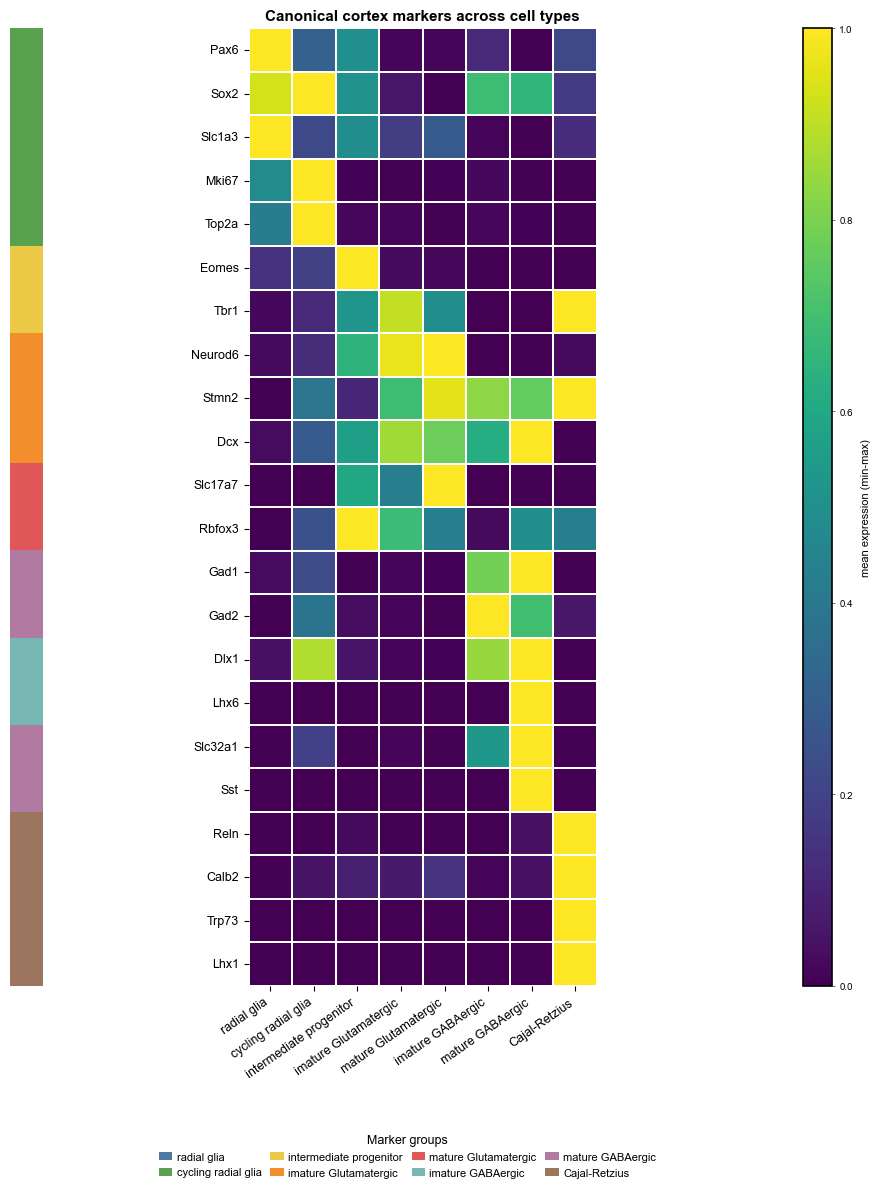

In [ ]:
import numpy as np
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib import gridspec

marker_sets = {
    "radial glia":             ["Pax6", "Sox2", "Slc1a3"],
    "cycling radial glia":     ["Pax6", "Sox2", "Slc1a3", "Mki67", "Top2a"],
    "intermediate progenitor": ["Eomes", "Neurod1", "Tbr1"],
    "imature Glutamatergic":   ["Neurod6", "Stmn2", "Dcx"],
    "mature Glutamatergic":    ["Slc17a7", "Camk2a", "Rbfox3"],
    "imature GABAergic":       ["Gad1", "Gad2", "Dlx1", "Lhx6"],
    "mature GABAergic":        ["Gad1", "Gad2", "Slc32a1", "Pvalb", "Sst"],
    "Cajal-Retzius":           ["Reln", "Calb2", "Trp73", "Lhx1"],
}

order_genes = [g for ct in CELL_TYPE_ORDER for g in marker_sets[ct]
               if g in gene_adata.var_names]
# Remove duplicates preserving order
seen = set()
order_genes = [g for g in order_genes if not (g in seen or seen.add(g))]

mean_exp = (
    gene_adata[:, order_genes].to_df()
    .join(gene_adata.obs["cell_type"])
    .groupby("cell_type").mean()
    .reindex(CELL_TYPE_ORDER).T
)
mean_exp = mean_exp.loc[lambda df: df.sum(axis=1) != 0]
scaled = (mean_exp - mean_exp.min(axis=1).values[:, None]) / (
    mean_exp.max(axis=1) - mean_exp.min(axis=1)
).values[:, None]

block_lookup = {g: ct for ct, genes in marker_sets.items() for g in genes}
row_blocks = [block_lookup[g] for g in scaled.index]
strip_rgb = np.array([CELL_TYPE_COLORS[b] for b in row_blocks])
strip_rgb = np.array([plt.matplotlib.colors.to_rgb(c) for c in strip_rgb]).reshape(len(row_blocks), 1, 3)

fig = plt.figure(figsize=(1.05 * scaled.shape[1] + 2.2,
                          0.50 * scaled.shape[0] + 1.6))
gs = gridspec.GridSpec(1, 3, width_ratios=[0.04, 0.925, 0.035], wspace=0.03)

ax_strip = fig.add_subplot(gs[0, 0])
ax_strip.imshow(strip_rgb, aspect="auto")
ax_strip.axis("off")

ax_hm = fig.add_subplot(gs[0, 1])
sns.heatmap(scaled, cmap="viridis", vmin=0, vmax=1, square=True,
            linewidths=0.25, linecolor="white", cbar=False, ax=ax_hm)
ax_hm.set_xticklabels(ax_hm.get_xticklabels(), rotation=35, ha="right", fontsize=9)
ax_hm.set_yticklabels(ax_hm.get_yticklabels(), rotation=0, ha="right", fontsize=9)
ax_hm.set_title("Canonical cortex markers across cell types", fontsize=11, pad=6)
ax_hm.set_xlabel("")
ax_hm.set_ylabel("")

ax_cb = fig.add_subplot(gs[0, 2])
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, 1))
cb = plt.colorbar(sm, cax=ax_cb)
cb.set_label("mean expression (min-max)", fontsize=8, labelpad=6)
cb.ax.tick_params(labelsize=7, width=0.4, length=2)

handles = [Patch(facecolor=CELL_TYPE_COLORS[ct], label=ct) for ct in CELL_TYPE_ORDER]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.04),
           ncol=4, frameon=False, fontsize=8, title="Marker groups",
           title_fontsize=9, handlelength=1.2, handletextpad=0.4, columnspacing=0.8)
plt.subplots_adjust(bottom=0.12)
plt.show()

| Cell type | Key markers | Biological role |
|-----------|-------------|-----------------|
| **Radial glia** | *Pax6*, *Sox2*, *Slc1a3* | Apical neural stem cells; PAX6/SOX2 maintain multipotency, GLAST clears extracellular glutamate |
| **Cycling radial glia** | *Pax6*, *Sox2*, *Slc1a3*, *Mki67*, *Top2a* | Same stem-cell core + proliferation markers (S/G2/M phase) |
| **Intermediate progenitor** | *Eomes*, *Neurod1*, *Tbr1* | Tbr2+ transit-amplifying progenitors in the subventricular zone (Pax6 → Tbr2 → Tbr1 cascade) |
| **imature Glutamatergic** | *Neurod6*, *Stmn2*, *Dcx* | Newly born excitatory neurons; DCX marks migrating precursors before NeuN/VGLUT1 switch on |
| **mature Glutamatergic** | *Slc17a7*, *Camk2a*, *Rbfox3* | VGLUT1 loads glutamate into vesicles; CaMKII-α and NeuN mark fully differentiated excitatory neurons |
| **imature GABAergic** | *Gad1*, *Gad2*, *Dlx1*, *Lhx6* | Post-mitotic interneuron precursors from the medial ganglionic eminence, migrating tangentially |
| **mature GABAergic** | *Gad1*, *Gad2*, *Slc32a1*, *Pvalb*, *Sst* | Fully integrated inhibitory interneurons; VGAT loads GABA, PV/SST mark principal subclasses |
| **Cajal-Retzius** | *Reln*, *Calb2*, *Trp73*, *Lhx1* | Layer-I pioneer neurons secreting Reelin to orchestrate cortical lamination |

### Gene-level vs isoform-level clustering

We claimed that gene-level and isoform-level embeddings recover the same cell types. Let's test this by running **independent Leiden clustering** on both the gene and transcript matrices, then comparing the three labellings — known cell-type annotations, gene-level clusters, and isoform-level clusters — with a three-column Sankey diagram. Clean 1-to-1 flows confirm that collapsing to genes loses no cell-identity information, while the isoform matrix retains the splice-level detail needed for DIU.

In [ ]:
# Leiden on gene-level features (gene_adata already has PCA/neighbors from UMAP above)
sc.tl.leiden(gene_adata, resolution=0.6, key_added='leiden_gene')
print(f"Gene-level Leiden:    {gene_adata.obs['leiden_gene'].nunique()} clusters")

# Leiden on isoform-level features
adata_iso = adata.copy()
sc.pp.normalize_total(adata_iso, target_sum=1e4)
sc.pp.log1p(adata_iso)
sc.pp.highly_variable_genes(adata_iso, n_top_genes=3000)
sc.pp.pca(adata_iso)
sc.pp.neighbors(adata_iso)
sc.tl.leiden(adata_iso, resolution=0.6, key_added='leiden_iso')
print(f"Isoform-level Leiden: {adata_iso.obs['leiden_iso'].nunique()} clusters")

In [ ]:
import plotly.graph_objects as go

# Align labels across shared cells
common = adata.obs_names.intersection(gene_adata.obs_names).intersection(adata_iso.obs_names)
ct  = adata.obs.loc[common, 'cell_type'].astype(str)
gcl = 'Gene ' + gene_adata.obs.loc[common, 'leiden_gene'].astype(str)
icl = 'Iso ' + adata_iso.obs.loc[common, 'leiden_iso'].astype(str)

# Three column labels: cell type | gene clusters | isoform clusters
ct_labels  = CELL_TYPE_ORDER
gcl_labels = sorted(gcl.unique(), key=lambda x: int(x.split()[-1]))
icl_labels = sorted(icl.unique(), key=lambda x: int(x.split()[-1]))
all_labels = ct_labels + gcl_labels + icl_labels

idx = {v: i for i, v in enumerate(all_labels)}

source, target, value, link_color = [], [], [], []

# Left flows: cell type → gene cluster
for c in ct_labels:
    mask = ct == c
    for g in gcl_labels:
        n = int((mask & (gcl == g)).sum())
        if n > 0:
            source.append(idx[c]); target.append(idx[g]); value.append(n)
            h = CELL_TYPE_COLORS[c]
            link_color.append(f"rgba({int(h[1:3],16)},{int(h[3:5],16)},{int(h[5:7],16)},0.35)")

# Right flows: gene cluster → isoform cluster
for g in gcl_labels:
    mask = gcl == g
    for ic in icl_labels:
        n = int((mask & (icl == ic)).sum())
        if n > 0:
            source.append(idx[g]); target.append(idx[ic]); value.append(n)
            link_color.append("rgba(150,150,150,0.25)")

node_colors = ([CELL_TYPE_COLORS[c] for c in ct_labels]
               + ['#666666'] * len(gcl_labels)
               + ['#999999'] * len(icl_labels))

fig = go.Figure(go.Sankey(
    node=dict(
        pad=12, thickness=18, line=dict(color='white', width=0.5),
        label=all_labels, color=node_colors,
    ),
    link=dict(source=source, target=target, value=value, color=link_color),
))
fig.update_layout(
    title_text="Cell-type annotation → Gene-level clusters → Isoform-level clusters",
    font_size=11, width=900, height=500,
)
fig.show()

## 4. Differential Isoform Usage (DIU)

**Why isoforms matter in the nervous system:** Alternative splicing expands the neuronal proteome, modulating ion-channel gating, synaptic scaffolding and axon guidance. More than half of all mammalian genes produce multiple splice variants, and neuronal tissues show the highest isoform diversity. Developmental stage-specific splicing programmes refine cell identity — classic examples include PSD-95 (*Dlg4*) and NMDAR subunits in maturing synapses.

### How SwitchSearch works

`SwitchSearch` tests whether the relative isoform composition of each gene differs across cell types. For each multi-isoform gene it:

1. Builds a **contingency table** (isoforms × cell types) from raw pseudobulk UMI counts.
2. Runs a **χ² test of independence** — null hypothesis: isoform proportions are the same in both groups.
3. Corrects for multiple testing with **Benjamini-Hochberg FDR**.
4. Computes the **Tilgner Δπ** effect size to quantify how large the switch is.

### Understanding Δπ (delta-pi)

Δπ measures the magnitude of an isoform switch between two cell types. For each gene, allos computes the **proportion** (π) of each isoform in group 1 and group 2, then takes the difference. Δπ is the sum of the two largest absolute isoform-proportion changes — capturing the dominant shift while being robust to noise in minor isoforms.

**Concrete example — Pkm in cycling radial glia vs mature glutamatergic neurons:**

| Isoform | π (Cyc. RG) | π (Mat. Glut.) | Δ (difference) |
|---------|:-----------:|:--------------:|:---------------:|
| Pkm-M2 (ENSMUST00000163694) | 0.87 | 0.14 | **+0.74** |
| Pkm-M1 (ENSMUST00000034834) | 0.13 | 0.86 | **−0.74** |

The two largest |Δ| values are 0.74 and 0.74 → **Δπ = 0.74**. This means 74% of Pkm usage flips between the two cell types — a near-complete isoform switch. By contrast, a gene with Δπ = 0.10 has only a subtle shift in isoform balance.

The sign indicates direction: positive Δπ means the dominant isoform shifted toward group 1, negative toward group 2.

In [ ]:
ss = SwitchSearch(adata, n_jobs=4)

diu_results = ss.find_switches_chi2(
    primary_col='cell_type',
    fdr=0.10,
    return_transcript_metrics=True
)

diu_results.sort_values('adj_pval').head(15)

**Key columns in the results table:**

| Column | Meaning |
|--------|---------|
| `gene_id` | Gene name |
| `group_1`, `group_2` | The two cell types being compared |
| `chi2_stat` | χ² test statistic — higher = more evidence against the null |
| `adj_pval` | Benjamini-Hochberg adjusted p-value (FDR) |
| `delta_pi` | Signed Δπ effect size (see above) |
| `transcript_id` | Individual transcript (one row per isoform when `return_transcript_metrics=True`) |
| `prop_group1`, `prop_group2` | Proportion of gene's UMIs from this isoform in each group |
| `delta_prop` | Difference in isoform proportion between groups |

Notice that **Pkm** appears as the top hit in multiple comparisons — the M1/M2 switch is consistent across the cycling-RG vs mature-Glutamatergic, IP vs mature-Glutamatergic, and other maturation contrasts. **Clta** is the second-strongest hit.

### Volcano plots

The table above shows that **Pkm** and **Clta** are the top DIU hits across many comparisons. To get a global view of how many isoform switches exist in each comparison — and how strong they are — we use volcano plots.

`find_switches_chi2` returns all genes with FDR < 0.10. On the volcano we apply stricter thresholds — **FDR < 0.05** and **|Δπ| ≥ 0.15** — to highlight only high-confidence switches with meaningful effect sizes.

**Reading the plot:**
- **x-axis (Δπ):** Effect size as defined above. Ranges from −1 to +1; larger absolute values = stronger switches.
- **y-axis (−log10 FDR):** Statistical significance. Higher = more significant.
- **Vertical dashed lines:** |Δπ| = 0.15 effect-size threshold.
- **Horizontal dashed line:** FDR = 0.05 significance threshold.
- **Orange points:** Genes passing **both** thresholds — high-confidence isoform switches.
- **`n=X`:** Number of unique switch genes in that comparison.

We focus on four biologically meaningful maturation comparisons rather than all 28 pairwise combinations:

In [ ]:
from allos.switch_search import volcano_grid, draw_volcano_panel

# Select biologically meaningful comparisons (maturation trajectories)
COMPARISONS = [
    ("cycling radial glia",  "radial glia"),
    ("radial glia",          "intermediate progenitor"),
    ("imature GABAergic",    "mature GABAergic"),
    ("imature Glutamatergic","mature Glutamatergic"),
]

# Filter results to selected pairs
sel = diu_results[
    diu_results.apply(
        lambda r: (r.group_1, r.group_2) in COMPARISONS
              or  (r.group_2, r.group_1) in COMPARISONS, axis=1
    )
]

# Abbreviated names for compact titles
ABBREV = {
    "cycling radial glia":     "Cyc. RG",
    "radial glia":             "RG",
    "intermediate progenitor": "IP",
    "imature GABAergic":       "Imm. GABA",
    "mature GABAergic":        "Mat. GABA",
    "imature Glutamatergic":   "Imm. Glut.",
    "mature Glutamatergic":    "Mat. Glut.",
    "Cajal-Retzius":           "C-R",
}

volcano_grid(
    sel,
    n_cols=4,
    figsize_per_panel=3.2,
    top_n=5,
    eff_cutoff=0.15,
    fdr_cutoff=0.05,
    label_cutoffs=False,
    abbrev=ABBREV,
)
plt.show()

For a manuscript figure or when presenting a specific comparison in detail, use `draw_volcano_panel` on a single axes:

In [ ]:
pair_df = diu_results[
    (diu_results.group_1 == "cycling radial glia") &
    (diu_results.group_2 == "mature Glutamatergic")
]

fig, ax = plt.subplots(figsize=(4, 3.5), dpi=200)
draw_volcano_panel(ax, pair_df, top_n=5, eff_cutoff=0.15, fdr_cutoff=0.05,
                   label_cutoffs=False, title="Cyc. RG vs Mat. Glut.")
plt.tight_layout()
plt.show()

## 5. Composed Figures

Now that we've identified genes with differential isoform usage, we want to visualise *what* the switch looks like. Allos **composed plots** pair transcript exon structures (left) with quantitative expression panels (right) in a single publication-ready figure.

All functions share the same interface: `transcript_data`, `adata`, `gene_id`, `group_col`. We demonstrate all seven plot types on **Clta** — the second-strongest DIU hit — then discuss which to choose:

| Plot type | Best for | Shows |
|-----------|----------|-------|
| **Heatmap** | Manuscript overview figures | PSI per isoform × cell type; GEX band shows total gene expression |
| **Dotplot** | Compact multi-gene panels | PSI as colour, prevalence as dot size |
| **Violin** | Showing per-cell distributions | Individual cell variation, not just group means |
| **Stacked bar** | Isoform proportions at a glance | How the "pie" is split across isoforms in each group |
| **UMAP** | Spatial localisation on the manifold | Which cells express which isoform |
| **Density** | Continuous gradients | KDE-smoothed isoform expression on the UMAP |
| **Replicates** | Batch concordance / QC | Per-replicate PSI values with box overlay — checks reproducibility |

### Heatmap

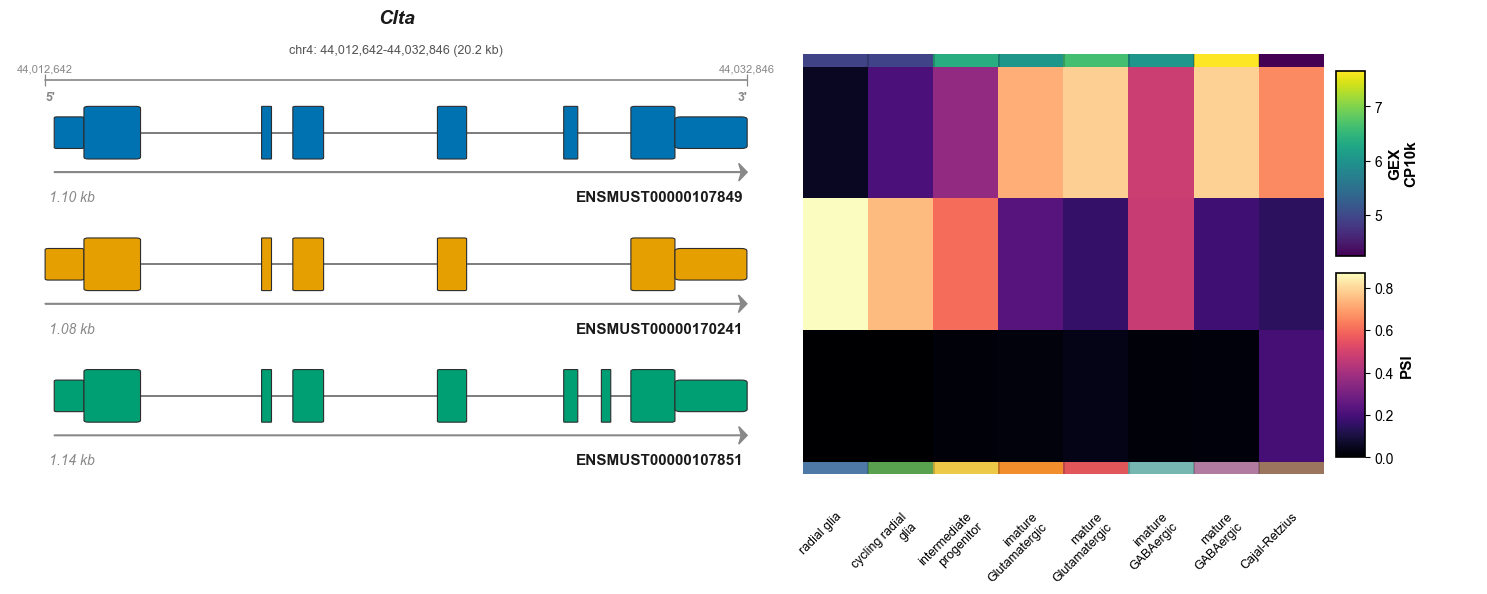

In [14]:
plot_isoform_heatmap_composed(
    transcript_data=td,
    adata=adata,
    gene_id='Clta',
    group_col='cell_type',
    top_n=3,
    group_color_map=CELL_TYPE_COLORS,
    visible_groups=CELL_TYPE_ORDER,
    add_group_color_band=True,
    add_gex_band=True,
)
plt.show()

### Dotplot

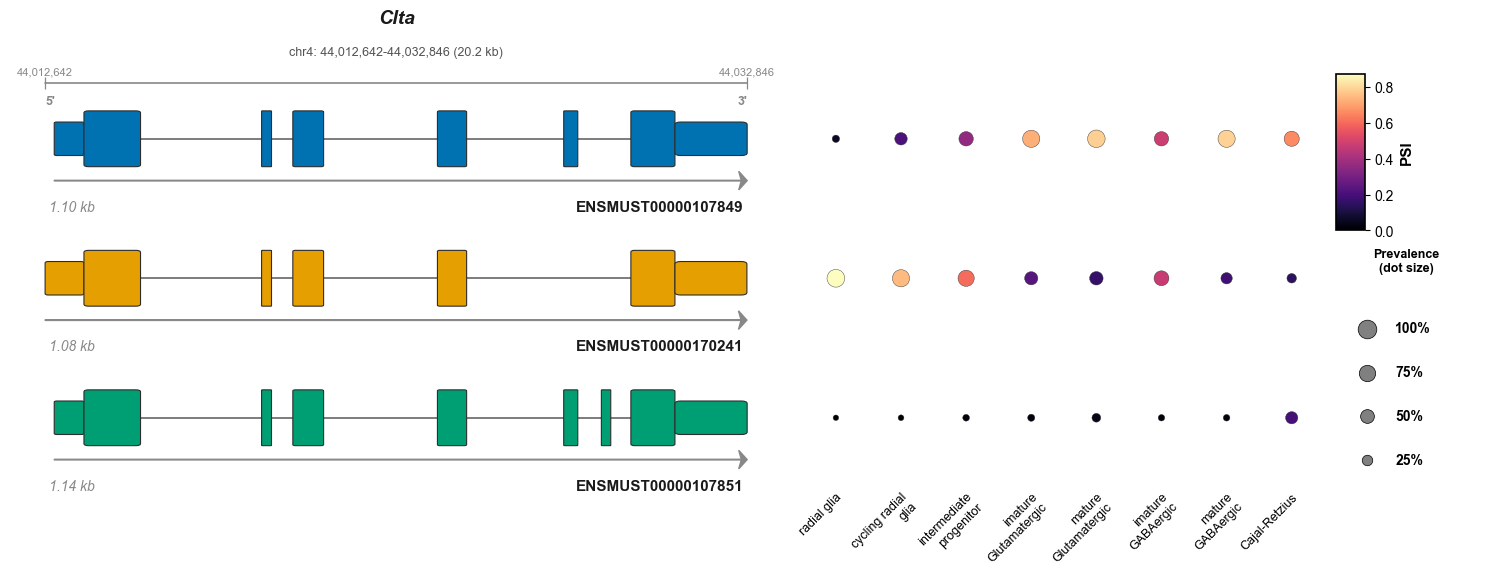

In [15]:
plot_isoform_dot_composed(
    transcript_data=td,
    adata=adata,
    gene_id='Clta',
    group_col='cell_type',
    top_n=3,
    group_color_map=CELL_TYPE_COLORS,
    visible_groups=CELL_TYPE_ORDER,
)
plt.show()

### Violin

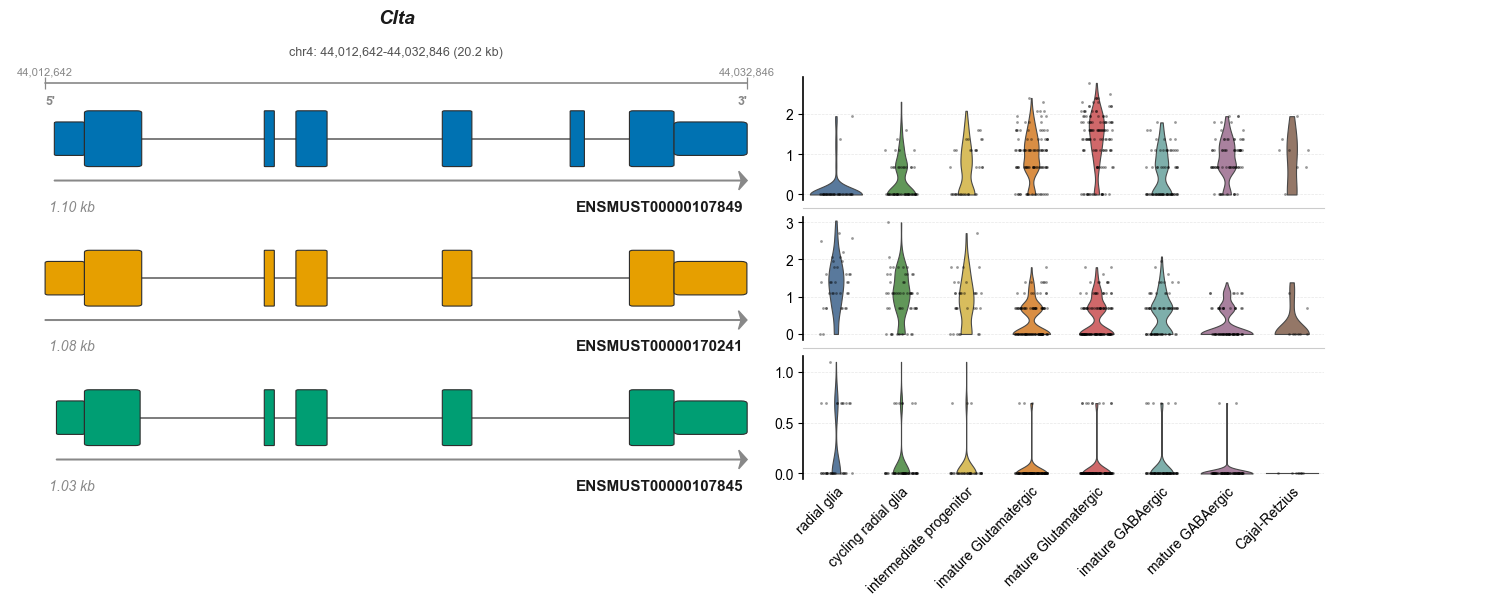

In [16]:
plot_isoform_violin_composed(
    transcript_data=td,
    adata=adata,
    gene_id='Clta',
    group_col='cell_type',
    top_n=3,
    group_color_map=CELL_TYPE_COLORS,
    visible_groups=CELL_TYPE_ORDER,
)
plt.show()

### Stacked bar

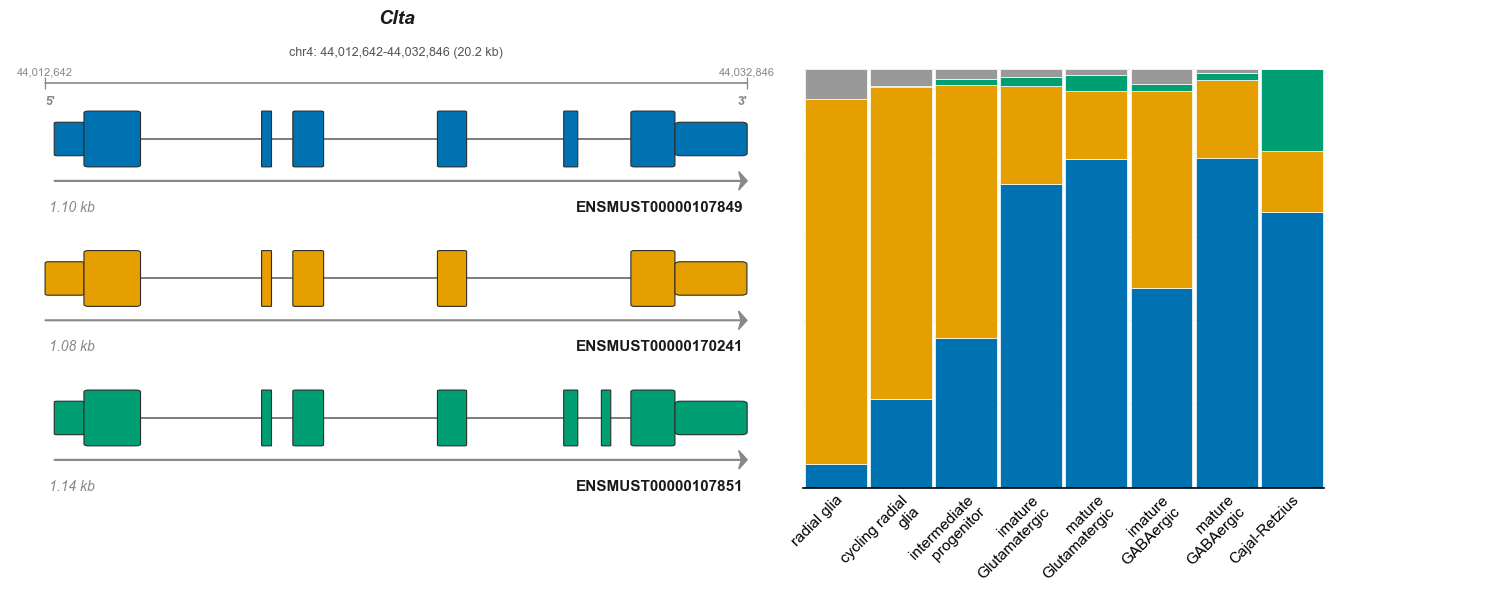

In [17]:
plot_isoform_stacked_bar_composed(
    transcript_data=td,
    adata=adata,
    gene_id='Clta',
    group_col='cell_type',
    top_n=3,
    group_color_map=CELL_TYPE_COLORS,
    visible_groups=CELL_TYPE_ORDER,
)
plt.show()

### UMAP

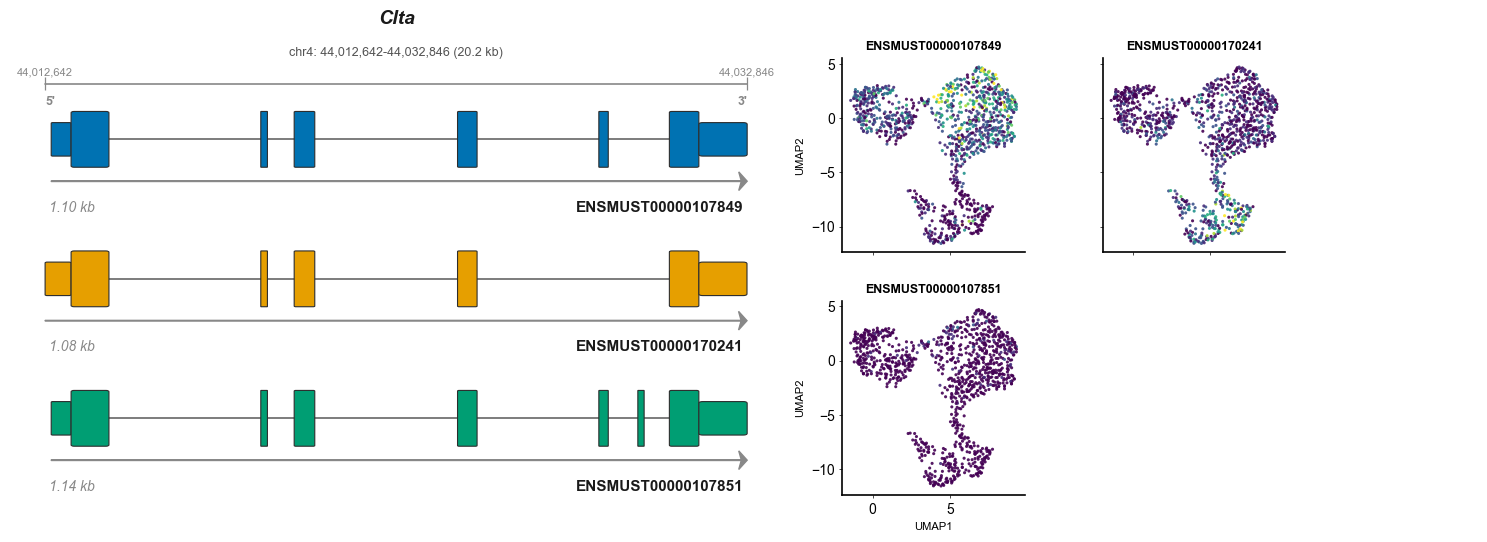

In [18]:
plot_isoform_umap_composed(
    transcript_data=td,
    adata=adata,
    gene_id='Clta',
    group_col='cell_type',
    top_n=3,
    group_color_map=CELL_TYPE_COLORS,
    visible_groups=CELL_TYPE_ORDER,
)
plt.show()

### Density

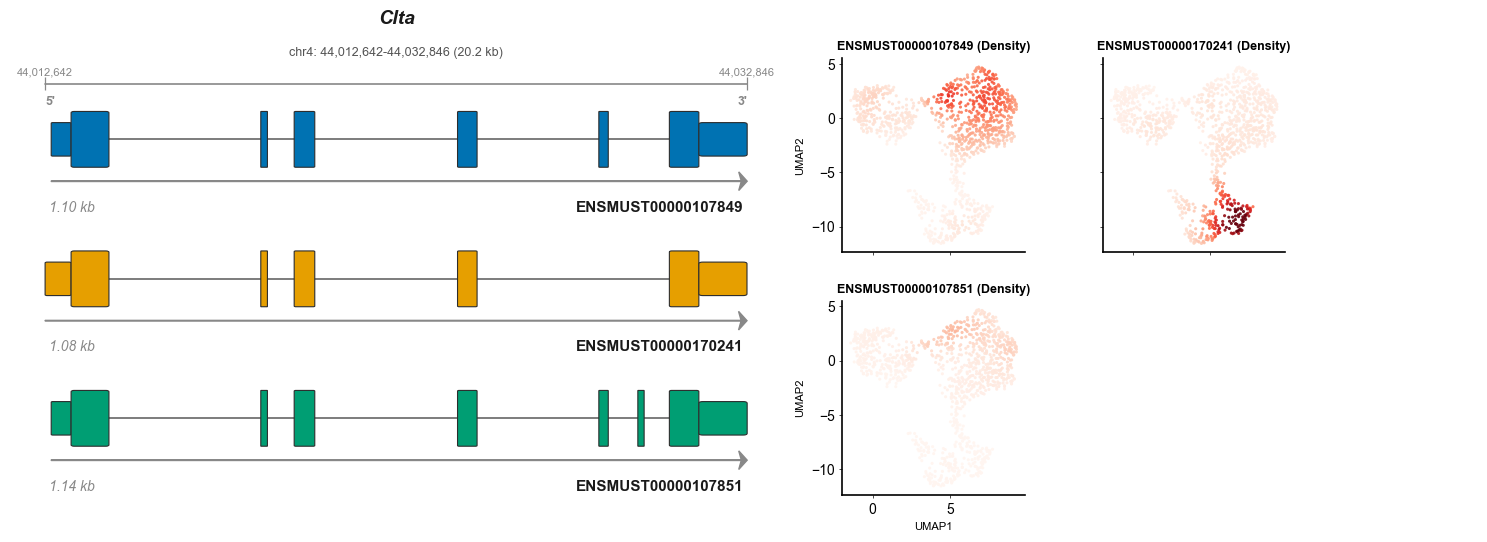

In [19]:
plot_isoform_density_composed(
    transcript_data=td,
    adata=adata,
    gene_id='Clta',
    group_col='cell_type',
    top_n=3,
    group_color_map=CELL_TYPE_COLORS,
    visible_groups=CELL_TYPE_ORDER,
)
plt.show()

### Biological interpretation

**Clta** (Clathrin light chain A) shows a clear isoform switch along the neuronal maturation trajectory:

| Comparison | Observation | Biology |
|------------|-------------|---------|
| immature → mature neurons | Clta-204 dominates in radial glia, cycling RG, IPs and immature neurons; Clta-206 takes over in both mature neuronal clusters. Cajal-Retzius cells remain mixed. | The alternative N-terminal acidic peptide alters self-assembly kinetics of the clathrin lattice, matching the increased synaptic-vesicle recycling demands as neurons mature. |

**Pkm** (Pyruvate kinase M) is the top DIU hit — the classic metabolic switch:

| Comparison | Observation | Biology |
|------------|-------------|---------|
| progenitors → mature neurons | PKM2 dominates in dividing radial glia / cycling RG; PKM1 appears in maturing neurons. | PKM2 favours anabolic (Warburg-like) metabolism in proliferating cells; the switch to PKM1 marks the transition to oxidative phosphorylation in post-mitotic neurons. |

### Read-level coverage

The composed plots above work from the count matrix. When you have access to the original BAM files, `plot_gene_coverage` shows per-cell-type read depth and **splice junction arcs** directly from the aligned reads — independent validation that the isoform switch is supported at the read level, not just the count level.

🎨 Plotting coverage for Clta (4:44012642-44032845)...


[W::hts_idx_load3] The index file is older than the data file: /data/analysis/data_mcandrew/00_allos_0.6_TAB/data/bams/s951_isobam.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /data/analysis/data_mcandrew/00_allos_0.6_TAB/data/bams/s951_isobam.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /data/analysis/data_mcandrew/00_allos_0.6_TAB/data/bams/s951_isobam.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /data/analysis/data_mcandrew/00_allos_0.6_TAB/data/bams/s951_isobam.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /data/analysis/data_mcandrew/00_allos_0.6_TAB/data/bams/s951_isobam.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /data/analysis/data_mcandrew/00_allos_0.6_TAB/data/bams/s951_isobam.bam.bai
[W::hts_idx_load3] The index file is older than the data file: /data/analysis/data_mcandrew/00_allos_0.6_TAB/data/bams/s951_isobam.bam.bai
[W::hts_idx_load3] The inde

✅ Done!


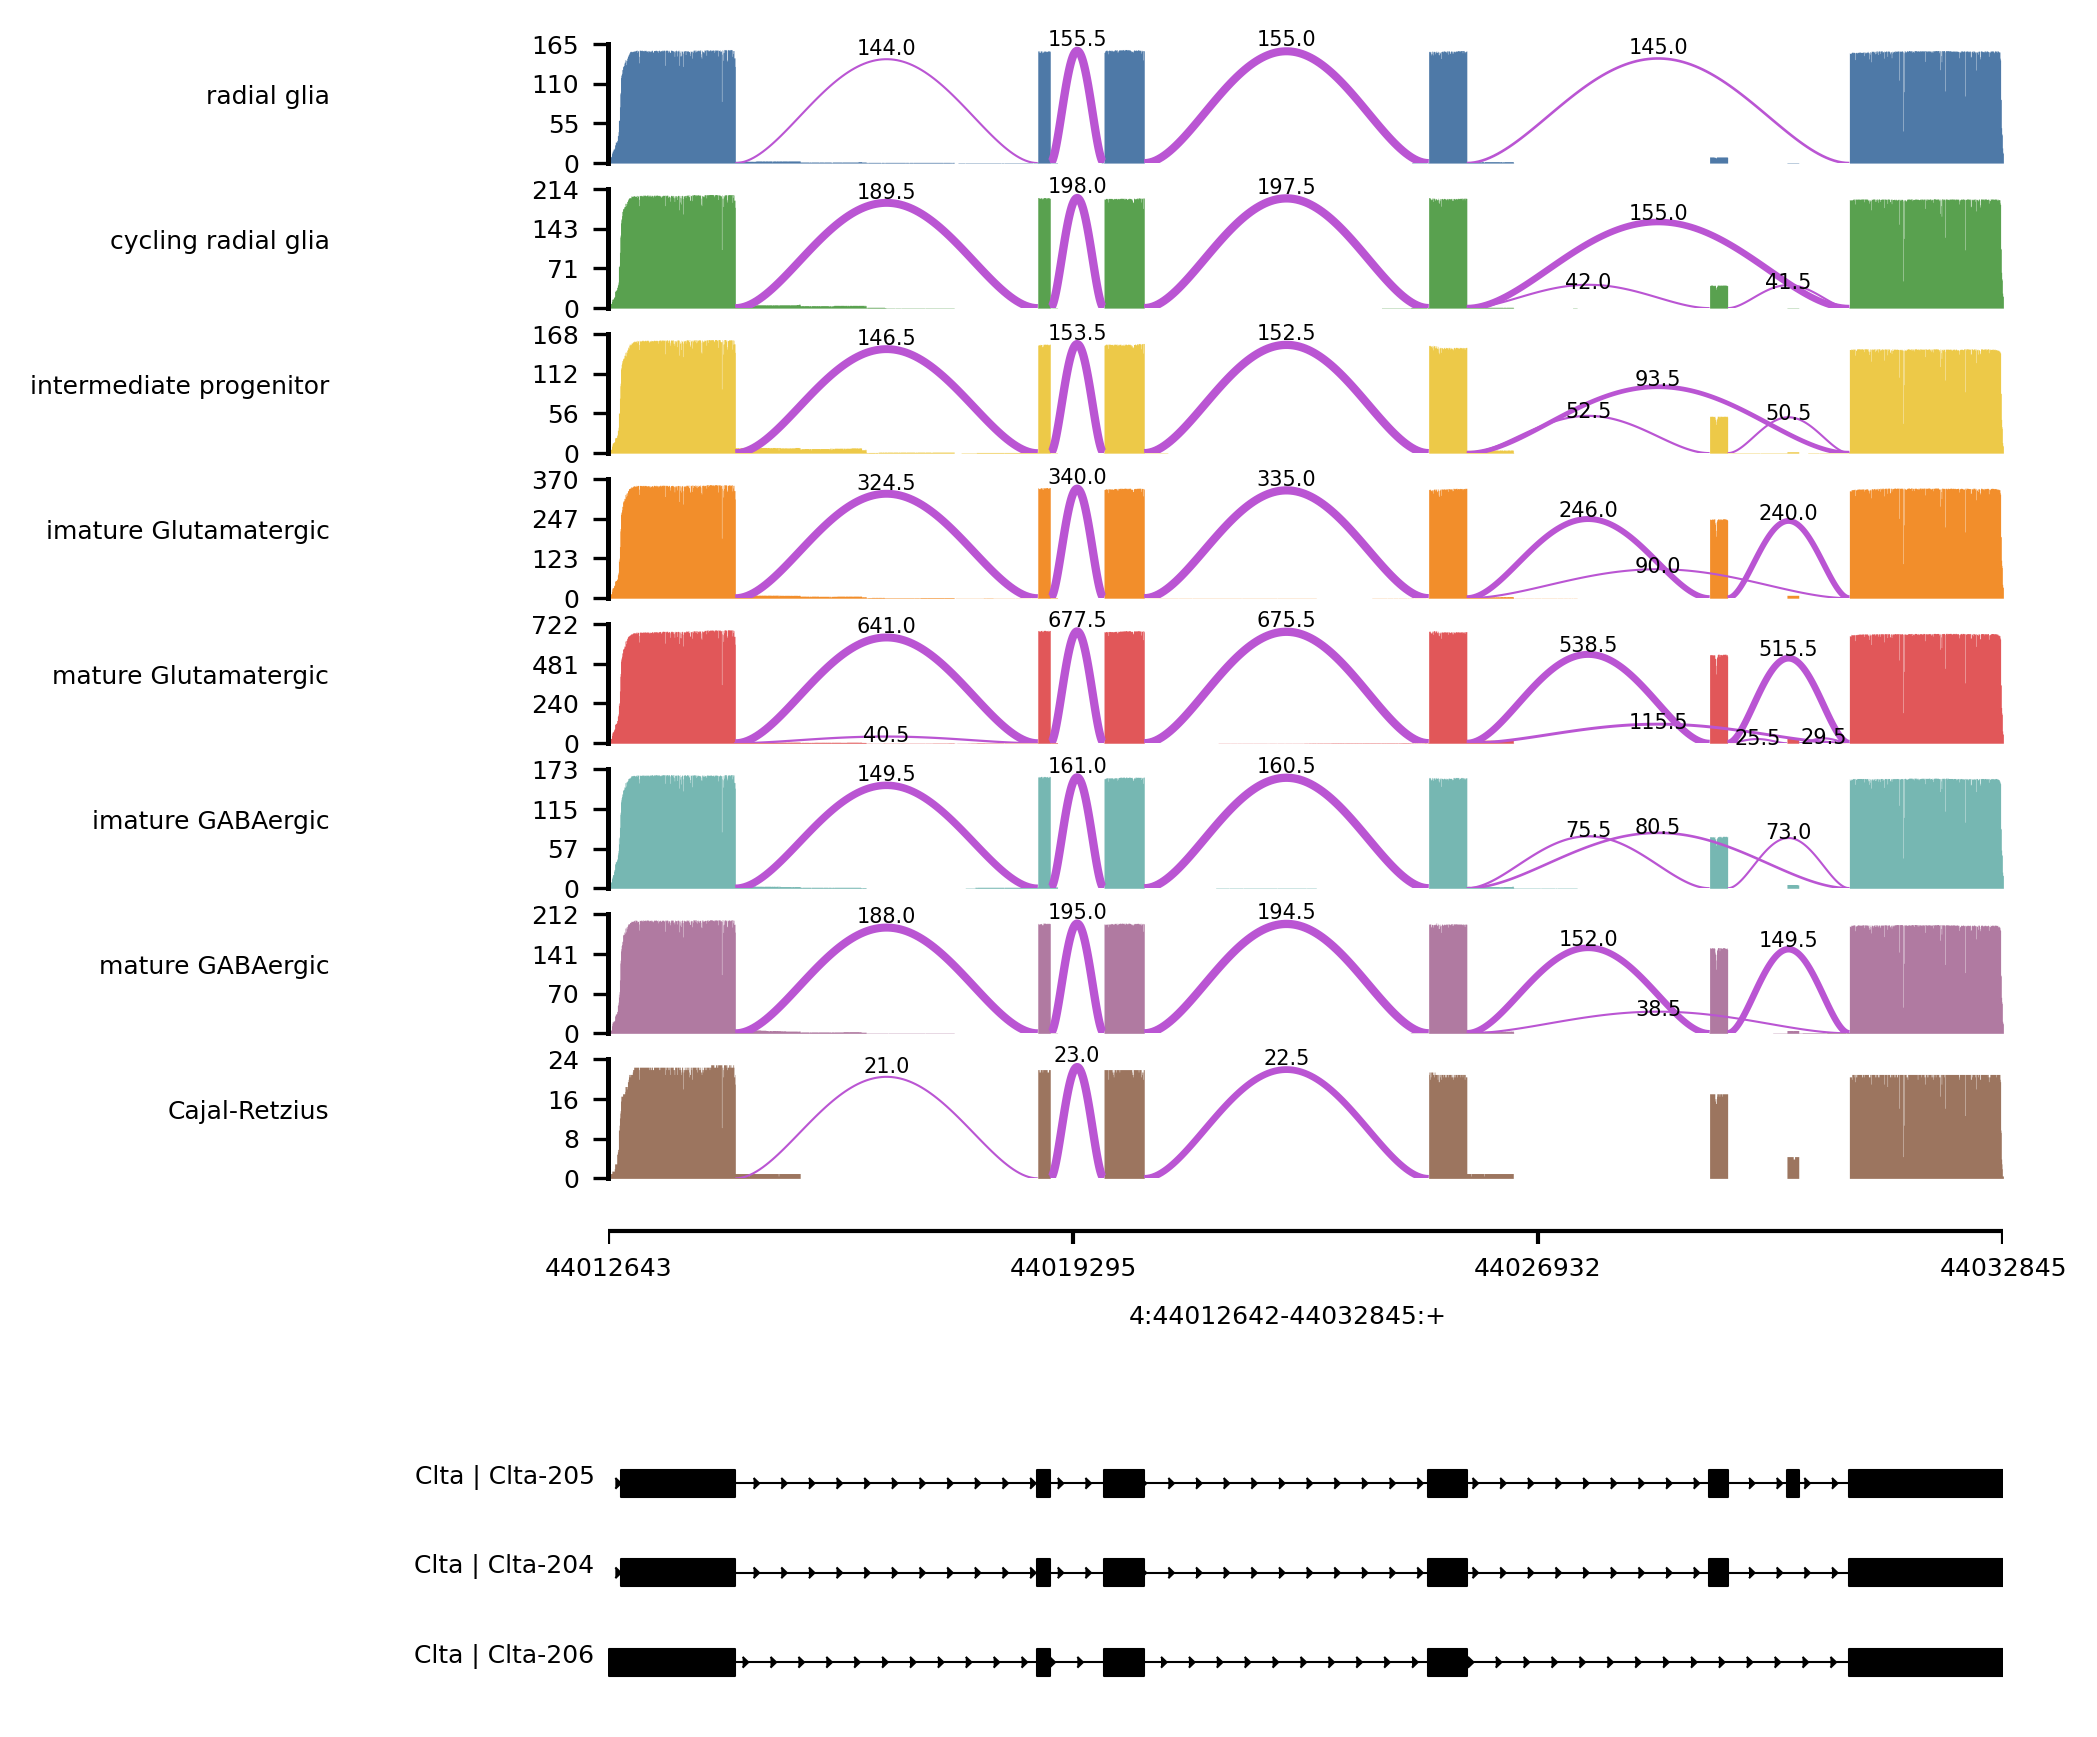

In [20]:
from allos.coverage_plots import plot_gene_coverage

bam_paths = {
    '0': '/data/analysis/data_mcandrew/00_allos_0.6_TAB/data/bams/s190_isobam.bam',
    '1': '/data/analysis/data_mcandrew/00_allos_0.6_TAB/data/bams/s951_isobam.bam',
}

plot_gene_coverage(
    adata,
    transcript_data=td,
    gene='Clta',
    groupby='cell_type',
    bam_paths=bam_paths,
    bam_column='batch',
    gtf_file=GTF_PATH,
    top_n=3,
    threshold=40,
    group_color_map=CELL_TYPE_COLORS,
    visible_groups=CELL_TYPE_ORDER,
)
plt.show()

### Replicate concordance

With two technical replicates in this dataset, we can check whether isoform proportions are consistent across batches — a key quality control for DIU results. The replicate plot shows per-replicate PSI values as individual points within each cell type, overlaid with box plots.

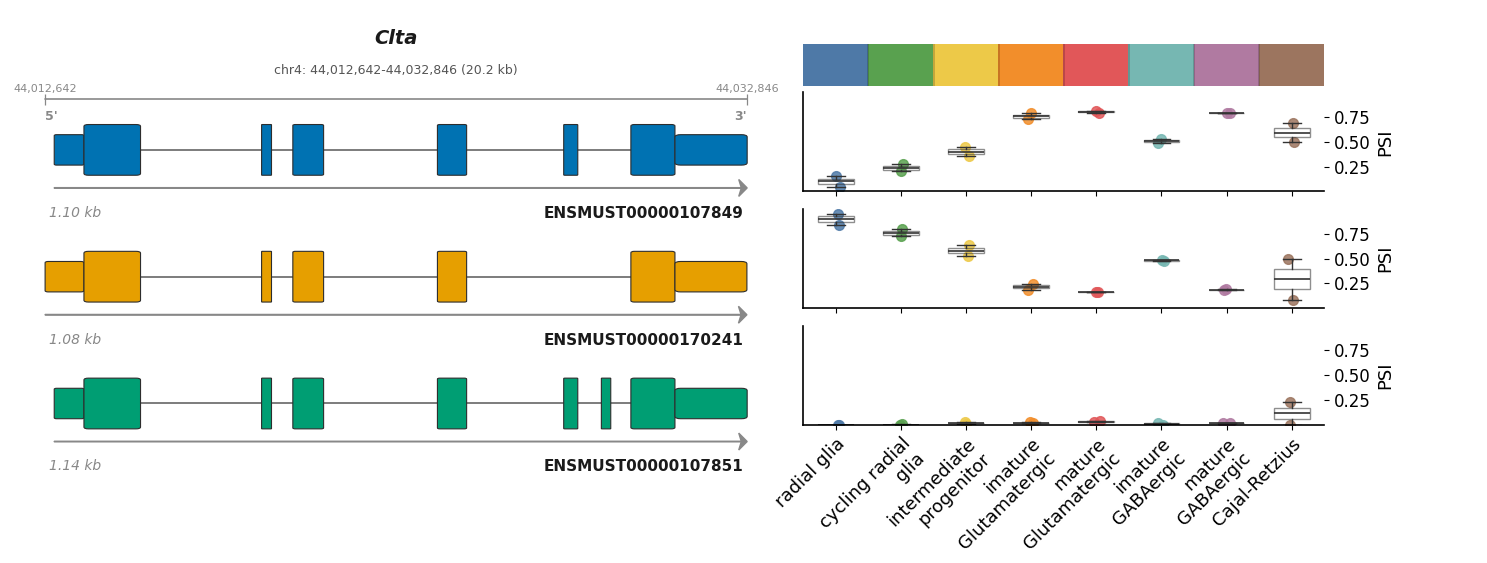

In [21]:
from allos.composed_plots import plot_isoform_replicates_composed

plot_isoform_replicates_composed(
    transcript_data=td,
    adata=adata,
    gene_id='Clta',
    group_col='cell_type',
    replicate_col='batch',
    top_n=3,
    group_color_map=CELL_TYPE_COLORS,
    visible_groups=CELL_TYPE_ORDER,
    add_group_color_band=True,
)
plt.show()

## 6. Protein Domain Visualisation

Allos can fetch protein domain annotations from **Ensembl** or **InterPro** and overlay them on transcript exon structures. This links splicing changes to functional protein regions — for example, showing that an alternatively-included exon encodes a specific Pfam domain.

We use two classes:
- `ProteinData` — fetches domains from REST APIs and maps amino-acid coordinates to genomic positions
- `ProteinPlots` — extends `TranscriptPlots` with a linearised protein track beneath each transcript

In [22]:
from allos.protein_data import ProteinData
from allos.protein_plots import ProteinPlots

pd = ProteinData(td, provider="ensembl")
pplot = ProteinPlots(transcript_data=td, protein_data=pd)

### Survey available domains

Before plotting, it helps to see what domain annotations the API returns for a gene. The `survey_gene_protein_domains` method shows you all available domain IDs grouped by source, and recommends filtering parameters.

In [23]:
survey = pplot.survey_gene_protein_domains("Clta")

DOMAIN SURVEY: Clta
Surveying 6 isoform(s): ENSMUST00000107845, ENSMUST00000107846, ENSMUST00000107847
  ... and 3 more

DOMAINS RETRIEVED: 12 unique domain IDs

Domains by ID prefix (for filtering with id_prefixes=[...]):
--------------------------------------------------------------------------------
  ⚠️ 'AF*' :   5 domains  (AF-B1AWD8-F1, AF-B1AWD9-F1, AF-B1AWE0-F1, ... (2 more))
  ✓ 'PS*' :   2 domains  (PS00224, PS00581)
  ⚠️ 'Co*' :   1 domains  (Coil)
  ✓ 'PF*' :   1 domains  (PF01086)
  ✓ 'PT*' :   1 domains  (PTHR10639)
  ⚠️ 'mo*' :   1 domains  (mobidb-lite)
  ⚠️ 'se*' :   1 domains  (seg)

FILTERING RECOMMENDATIONS

⚠️  Typically uninformative (EXCLUDE these):
   AF-* : AlphaFold mappings (not functional domains)
   mo*  : mobidb-lite disorder predictions
   se*  : seg low-complexity regions
   Co*  : Coiled-coil predictions
   1.*  : Generic CATH/Gene3D (entire protein)

✓  Typically informative (KEEP these):
   PF*  : Pfam protein families
   SM*  : SMART domains
   PS*  

### Plot transcript structures with protein domains

`draw_gene_with_protein_domains` selects the top-expressed isoforms from the AnnData object, draws their exon structure, and adds a linearised protein track showing domain positions mapped back to the genome.

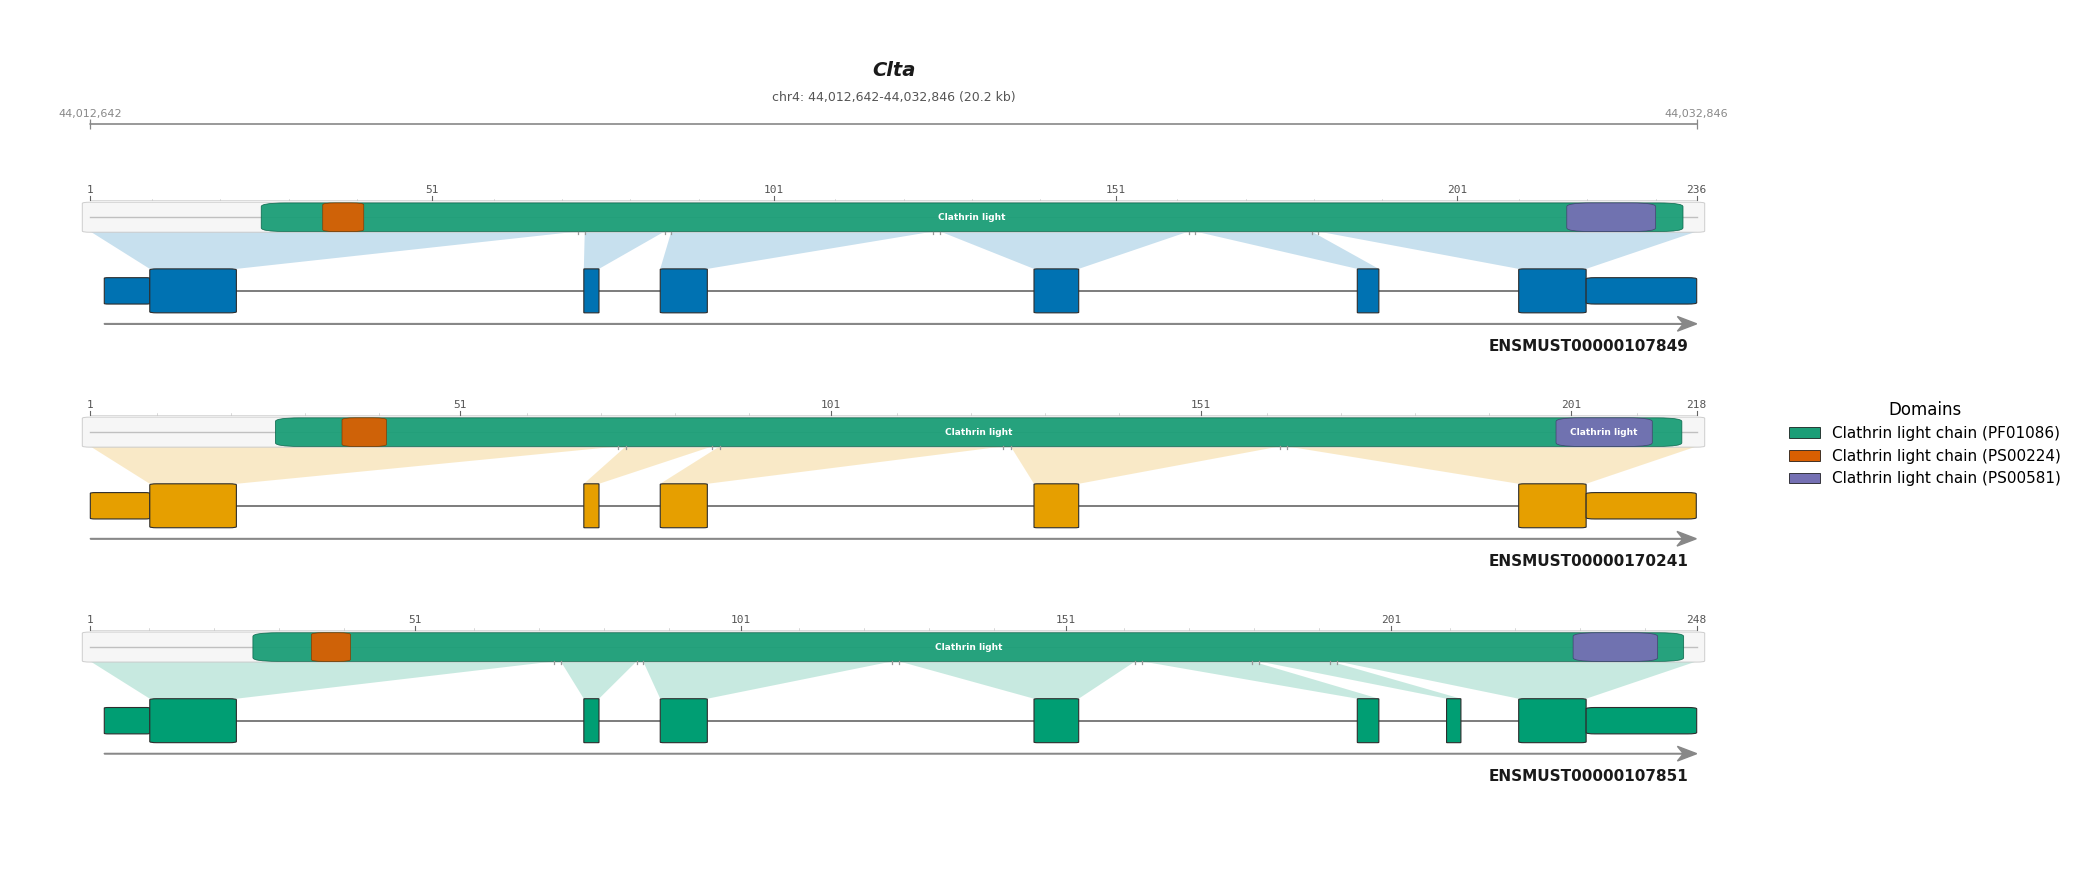

In [24]:
fig = pplot.draw_gene_with_protein_domains(
    gene="Clta",
    adata=adata,
    top_n=3,
    provider="ensembl",
    id_prefixes=["PF", "SM", "PS", "cd", "SS"],
    max_domains=8,
)
plt.show()

### Compare providers: Ensembl vs InterPro

InterPro aggregates domains from multiple member databases (Pfam, SMART, PROSITE, CDD, …) and often returns richer annotations. Note that InterPro annotations are only available for the canonical transcript.

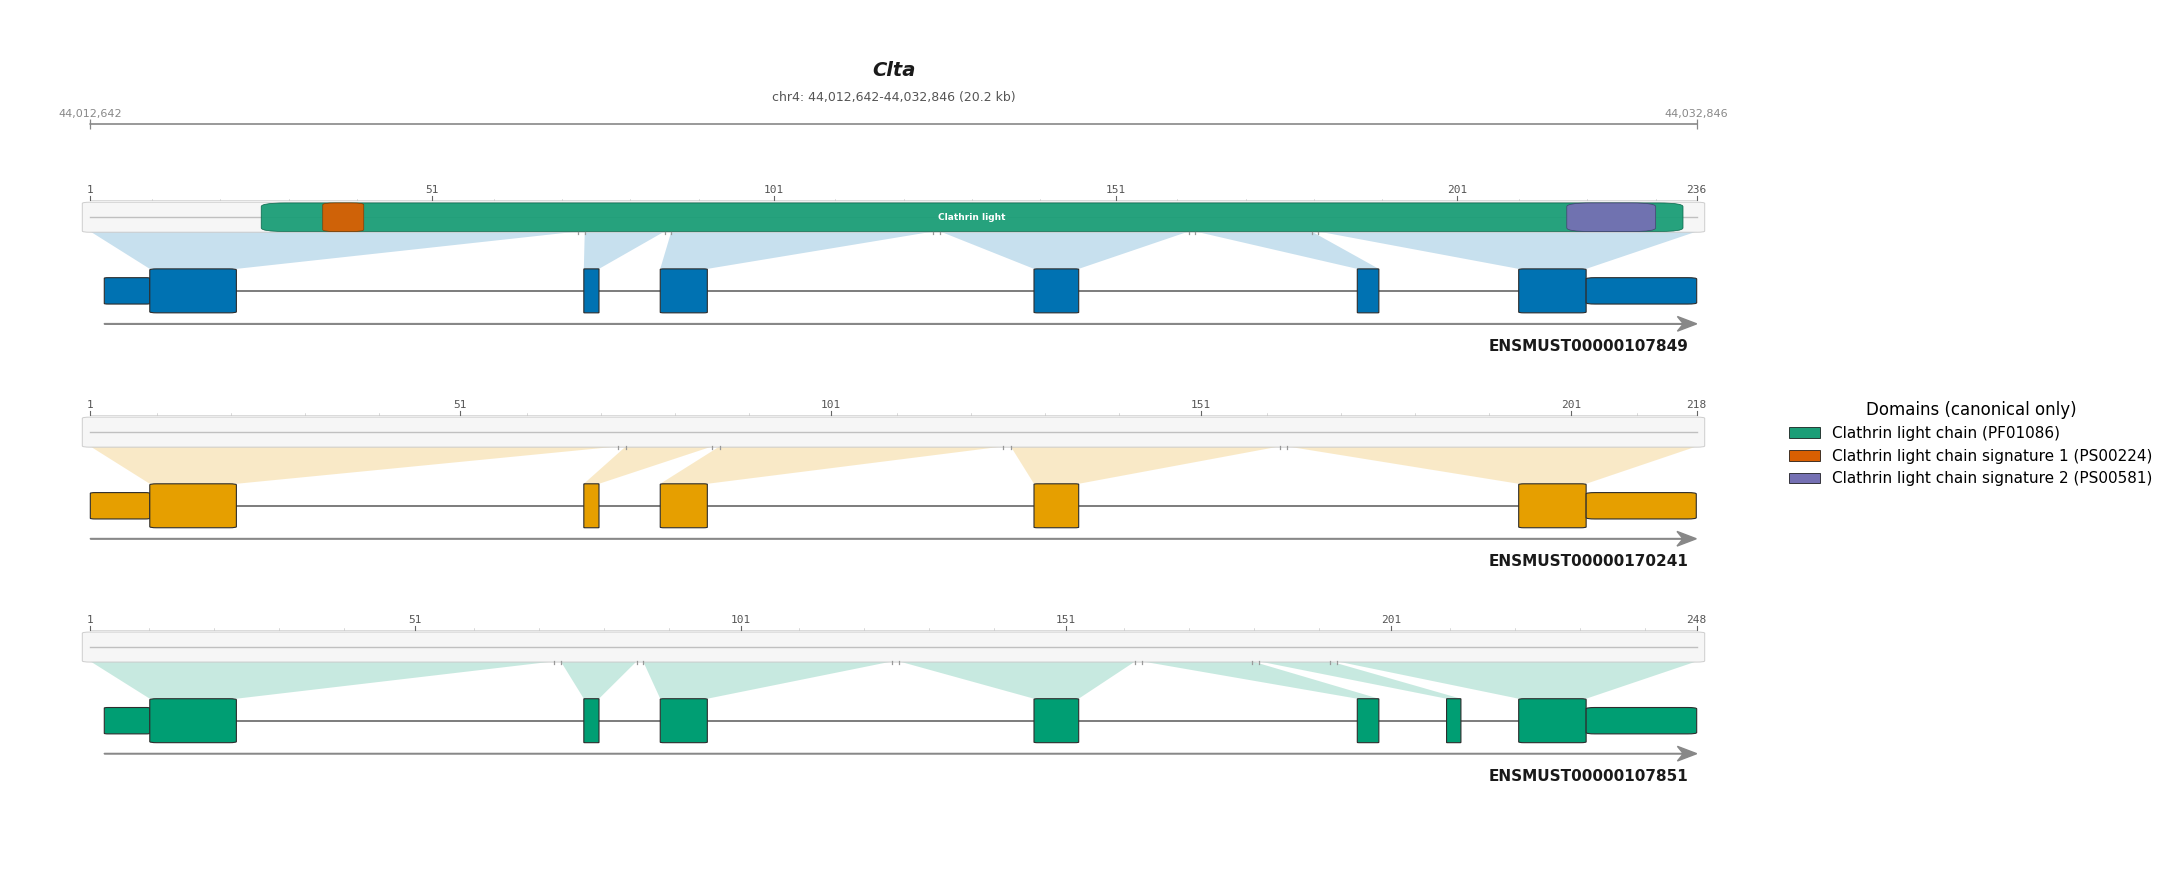

In [25]:
fig = pplot.draw_gene_with_protein_domains(
    gene="Clta",
    adata=adata,
    top_n=3,
    provider="interpro",
    id_prefixes=["PF", "SM", "PS", "cd", "SS"],
    max_domains=8,
)
plt.show()

### Protein domains on a DIU hit

Let's visualise the protein domains for **Pkm**, the top differentially-used gene from the SwitchSearch results. The isoform switch between Pkm-M1 and Pkm-M2 is a well-known metabolic switch — the protein domain view shows exactly which exon encodes the differing region.

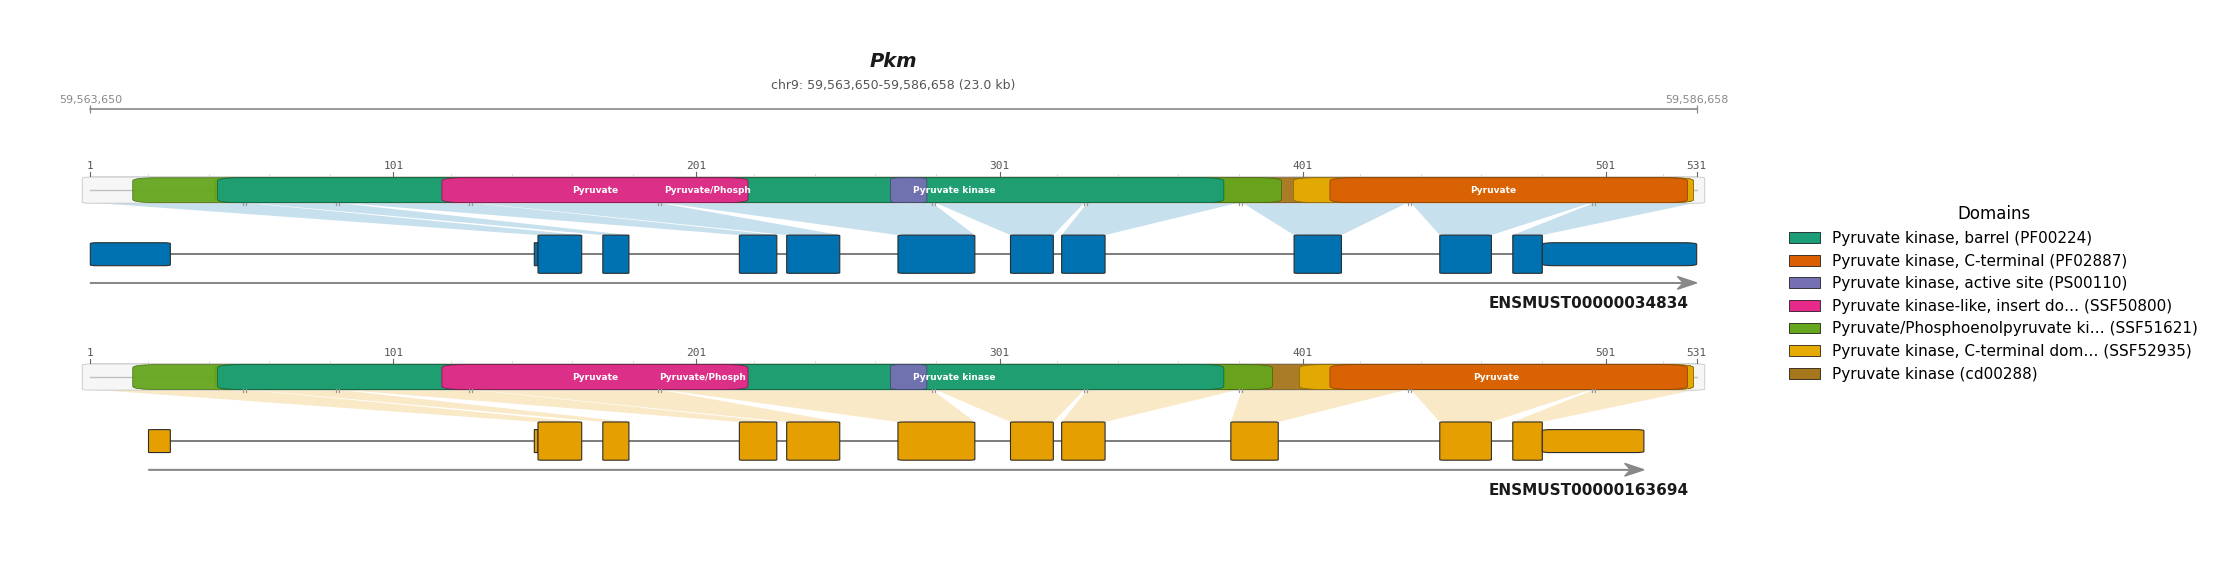

In [26]:
fig = pplot.draw_gene_with_protein_domains(
    gene="Pkm",
    adata=adata,
    top_n=2,
    provider="ensembl",
    id_prefixes=["PF", "SM", "PS", "cd", "SS"],
    max_domains=8,
)
plt.show()

## 7. Exercises

Try these on your own to consolidate what you've learned.

### Exercise 1: Explore another DIU gene
Pick a different significant gene from the `diu_results` table (e.g. row 2–5). Generate a composed heatmap **and** a protein domain plot for it. Does the alternatively-used exon overlap a known protein domain?

```python
# Hint: get gene names from the DIU results
diu_results.sort_values('adj_pval').head(10)[['gene_id', 'adj_pval', 'max_delta']].drop_duplicates('gene_id')
```

### Exercise 2: Filtering thresholds
Re-run the preprocessing with a stricter abundance filter (e.g. `threshold_pct=5` instead of `2`). How does this affect the number of retained transcripts? Does it change which genes appear as significant in the DIU test?

### Exercise 3: Pairwise vs global DIU
`SwitchSearch.find_switches_chi2` tests all pairwise cell-type comparisons. Pick one specific pair (e.g. `"cycling radial glia"` vs `"mature Glutamatergic"`) and filter the results. Which genes are unique to this comparison vs the global results?

```python
# Hint
pair = diu_results[
    (diu_results.group_1 == "cycling radial glia") & 
    (diu_results.group_2 == "mature Glutamatergic")
].sort_values('adj_pval')
```

### Exercise 4: InterPro vs Ensembl domains
For the same gene, compare the protein domain annotations from Ensembl and InterPro. Which provider gives more informative domains? Try different `id_prefixes` to filter for specific databases (e.g. `["PF"]` for Pfam only).

### Exercise 5: Interpret a composed figure
Generate all six composed plot types (heatmap, dotplot, violin, stacked bar, UMAP, density) for **Pkm**. For each plot type, write one sentence describing what biological insight it best highlights. Which plot type would you choose for a manuscript figure, and why?